In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import instruments as inst
import copy
import numpy as np
import json

# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 760
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 19866.    23740.5  -22265.5   22477.5   13337.5   22094.5  -15543.5
  21181.5   -1825.5   18824.      110.    19143.5  -13889.    16562.
  12902.    17644.5  -14556.5   16335.5   13596.5   17653.    -3387.5
  18323.5    2077.    18801.5   12197.    21847.   -14083.    21064.
  20120.5   24137.5  -22436.    22875.5   15688.5   22780.   -17572.
  21883.    20161.    24039.5  -22381.    22674.75  12334.5   22139.5
 -14414.    21295.5   -3194.    18743.5    1604.5   19184.5  -14446.
  16557.    13502.    17758.   -13795.5   16484.5   13102.    17583.5
  -1688.5   18628.      432.    18979.5   13512.5   22046.   -15333.
  21198.5    3221.5   20141.    -4612.    20053.    17069.5   23260.
 -18755.5   22276.    20285.    24323.   -22433.    22960.    11280.5
  22175.   -13264.    21412.    -4602.    18669.     3141.5   19245.
 -14799.5   16621.5   13886.    17961.   -12891.    16749.    12270.
  17794.     -109.    18976.    -1109.    19212.    -9865.5   1743

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

3.11 µs ± 182 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_restrictive_HWP_FLC_with_IMR_offset_fixed_EM_gain_with_dichroic_best_fit.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].setdefault("delta_theta", 0.0)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = past_fit["image_rotator"]["delta_theta"]
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.0798052820150867 # from EM gain measurements

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

{'dichroic': {'phi': -1.12634729936643, 'epsilon': 0.09213667482955061, 'theta': -0.7211513949440611}, 'flc': {'phi': 3.2247610235843807, 'delta_theta': 0.8875636750432755}, 'optics': {'phi': 1.0807295869014508, 'epsilon': 0.06910187500867057, 'theta': -69.62711175875525}, 'image_rotator': {'phi': 3.079250623531564, 'delta_theta': -0.999900875251629}, 'hwp': {'phi': 3.0470632498652788, 'delta_theta': -1.1292793528354483}, 'lp': {'theta': 1.4028111582126743}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.45918489 0.45863448 0.02247608 0.        ]
 [0.45918489 0.45863448 0.02247608 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -1.12634729936643, 'epsilon': 0.09213667482955061, 'theta': -0.7211513949440611}, 'flc': {'phi': 3.2247610235843807, 'delta_theta': 0.8875636750432755}, 'optics': {'phi': 1.0807295869014508, 'epsilon': 0.06910187500867057, 'theta': -69.62711175875525}, 'image_rotator': {'phi': 3.079250623531564, 'delta_theta': -0.999900875251629}, 'hwp': {'phi': 3.0470632498652788, 'delta_theta': -1.1292793528354483}, 'lp': {'theta': 1.4028111582126743}}
logl value: 9439.82111397425


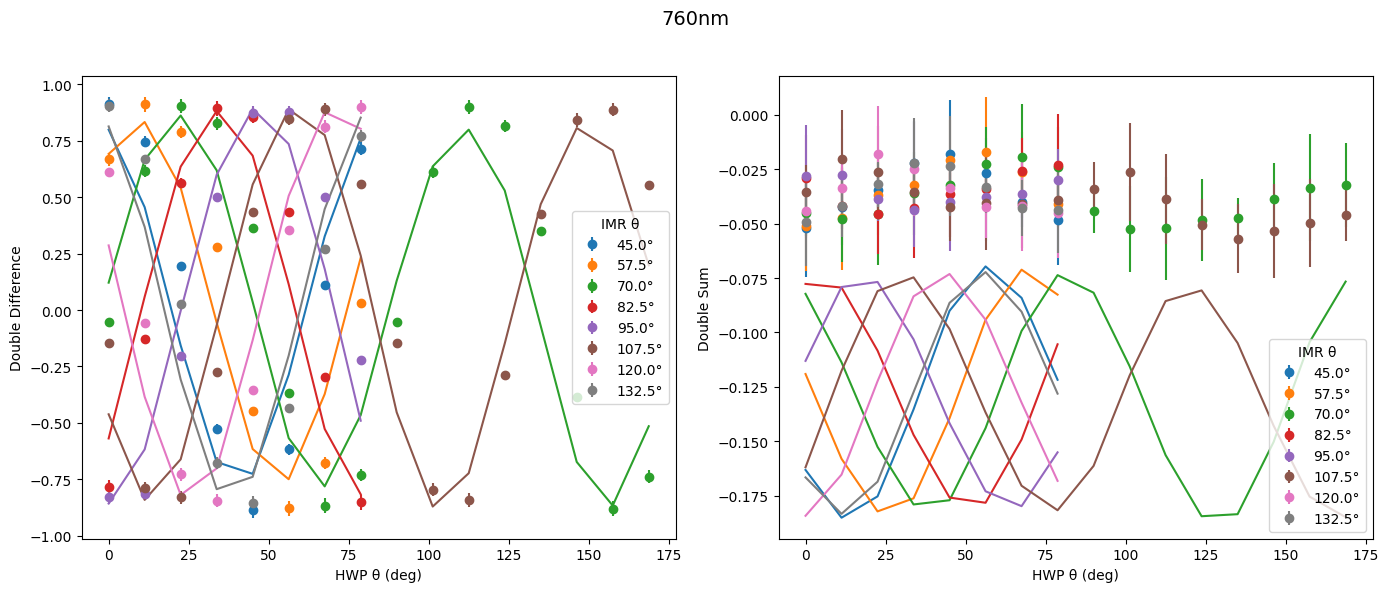

In [6]:
# Fittin for all parameters
p0 = past_fit

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -1.12634729936643, 'epsilon': 0.09213667482955061, 'theta': -0.7211513949440611}, 'flc': {'phi': 3.2247610235843807, 'delta_theta': 0.8875636750432755}, 'optics': {'phi': 1.0807295869014508, 'epsilon': 0.06910187500867057, 'theta': -69.62711175875525}, 'image_rotator': {'phi': 3.079250623531564, 'delta_theta': -0.999900875251629}, 'hwp': {'phi': 3.0470632498652788, 'delta_theta': -1.1292793528354483}, 'lp': {'theta': 1.4028111582126743}}
Iteration #: 1
logl_value: 142.53812259451638
Best Fit Parameters: [-2.16239348e+00  2.09735021e-03 -5.60654543e-01  3.15494739e+00
  8.31489837e-01 -1.12992042e-01  1.63077503e-01 -8.62863719e+01
  3.16121135e+00 -9.99718421e-01  2.83207126e+00 -2.04573570e+00
  1.53540040e+00]


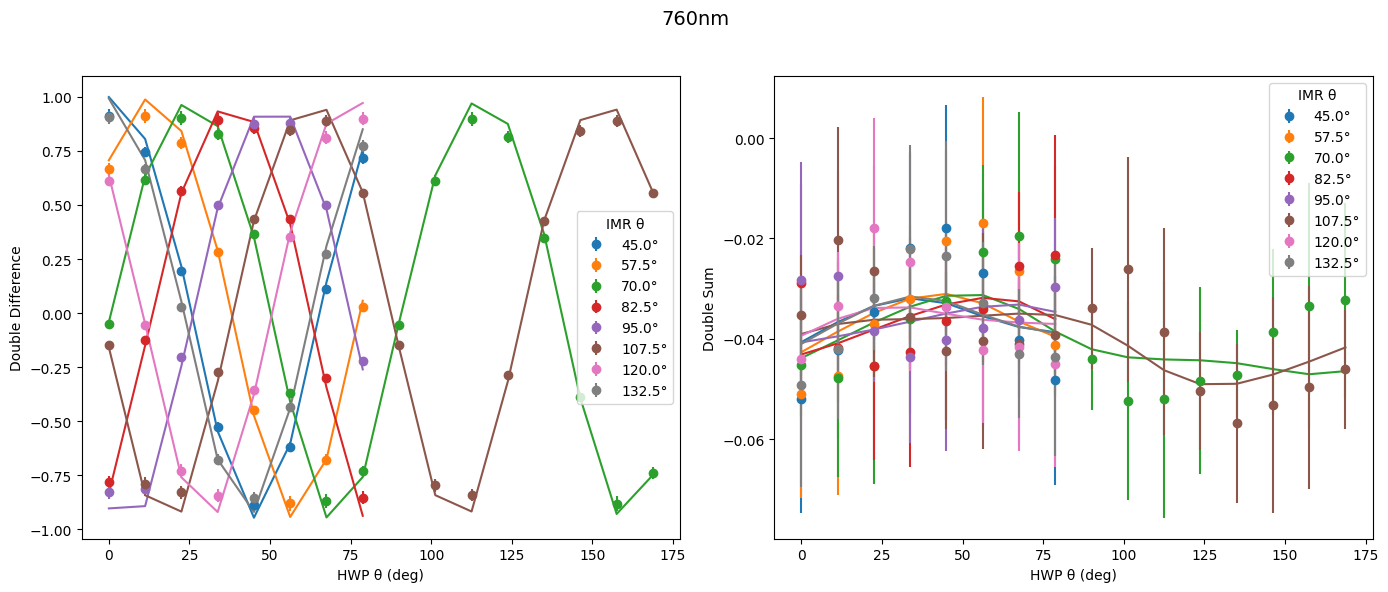

After p0: {'dichroic': {'phi': -2.1623934826851148, 'epsilon': 0.0020973502053811943, 'theta': -0.5606545431990075}, 'flc': {'phi': 3.1549473900467593, 'delta_theta': 0.8314898374552229}, 'optics': {'phi': -0.11299204243692984, 'epsilon': 0.16307750301254698, 'theta': -86.28637185194128}, 'image_rotator': {'phi': 3.1612113522016987, 'delta_theta': -0.9997184208839562}, 'hwp': {'phi': 2.8320712641270624, 'delta_theta': -2.0457356982203603}, 'lp': {'theta': 1.53540039779418}}
Before p0: {'dichroic': {'phi': -2.1623934826851148, 'epsilon': 0.0020973502053811943, 'theta': -0.5606545431990075}, 'flc': {'phi': 3.1549473900467593, 'delta_theta': 0.8314898374552229}, 'optics': {'phi': -0.11299204243692984, 'epsilon': 0.16307750301254698, 'theta': -86.28637185194128}, 'image_rotator': {'phi': 3.1612113522016987, 'delta_theta': -0.9997184208839562}, 'hwp': {'phi': 2.8320712641270624, 'delta_theta': -2.0457356982203603}, 'lp': {'theta': 1.53540039779418}}
Iteration #: 2
logl_value: 138.7797345058

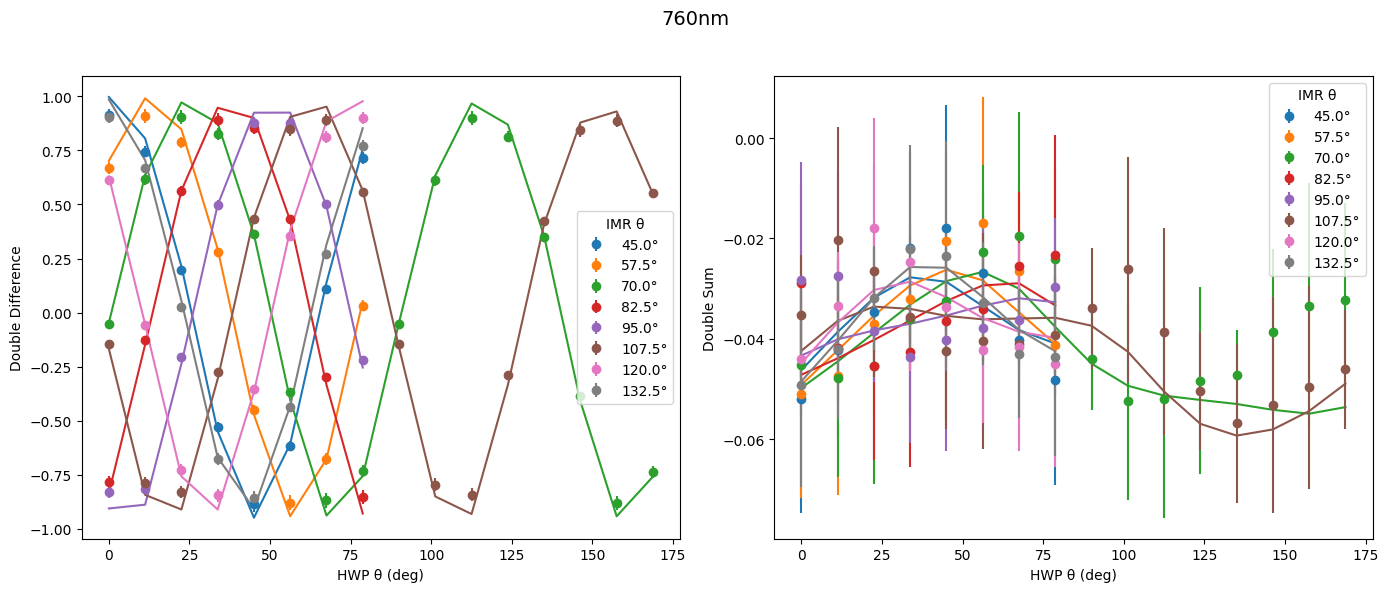

After p0: {'dichroic': {'phi': -0.8956181572730193, 'epsilon': 0.005271712725415809, 'theta': -3.9993155783495364}, 'flc': {'phi': 3.02853200677794, 'delta_theta': 1.1712371323161777}, 'optics': {'phi': -0.23000566058585592, 'epsilon': 0.15845499212835834, 'theta': -84.96167776472413}, 'image_rotator': {'phi': 3.1790319183953013, 'delta_theta': -0.9961167490617853}, 'hwp': {'phi': 2.8630507889594856, 'delta_theta': -1.4688268770229946}, 'lp': {'theta': 3.854878224647363}}
Before p0: {'dichroic': {'phi': -0.8956181572730193, 'epsilon': 0.005271712725415809, 'theta': -3.9993155783495364}, 'flc': {'phi': 3.02853200677794, 'delta_theta': 1.1712371323161777}, 'optics': {'phi': -0.23000566058585592, 'epsilon': 0.15845499212835834, 'theta': -84.96167776472413}, 'image_rotator': {'phi': 3.1790319183953013, 'delta_theta': -0.9961167490617853}, 'hwp': {'phi': 2.8630507889594856, 'delta_theta': -1.4688268770229946}, 'lp': {'theta': 3.854878224647363}}
Iteration #: 3
logl_value: 20.360518624382294

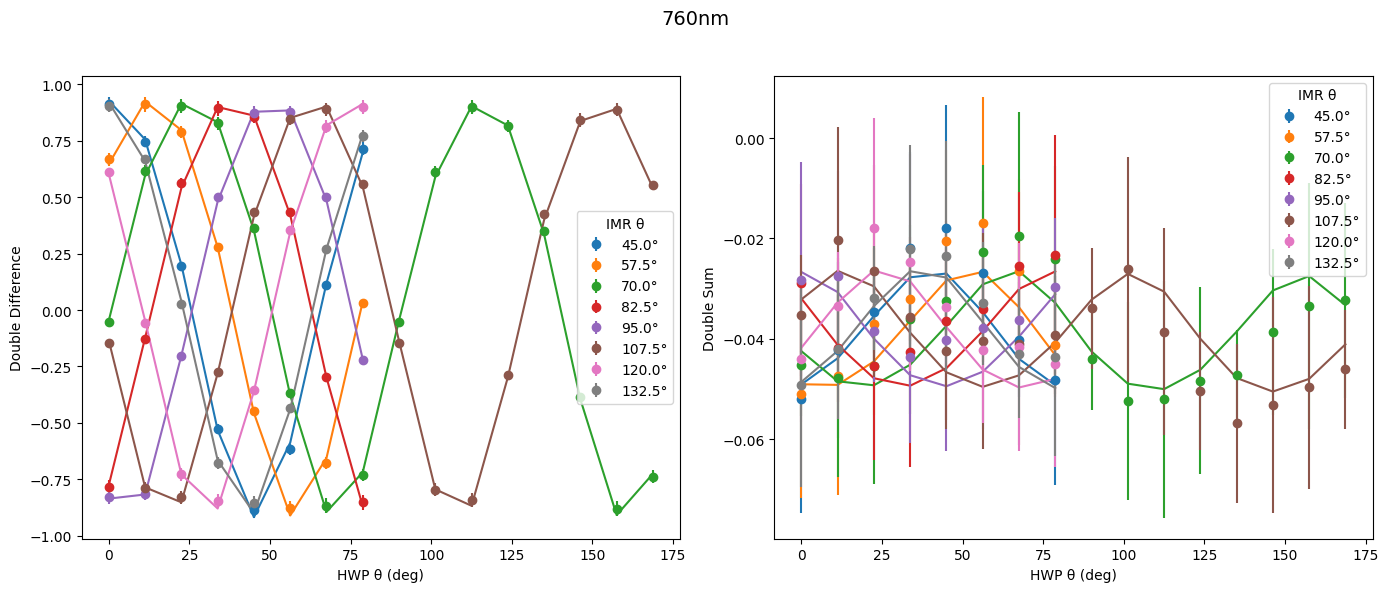

After p0: {'dichroic': {'phi': -2.343327765242976, 'epsilon': 2.2616187383027241e-07, 'theta': -9.358349221521443}, 'flc': {'phi': 2.8091523827963334, 'delta_theta': -2.043717184740011}, 'optics': {'phi': -1.6189134774207083, 'epsilon': 0.16597499065370486, 'theta': -88.82316639074062}, 'image_rotator': {'phi': 3.1471003685400447, 'delta_theta': -0.9560106416346033}, 'hwp': {'phi': 3.118236664947524, 'delta_theta': -3.2076749321940863}, 'lp': {'theta': -4.686899743939815}}
Before p0: {'dichroic': {'phi': -2.343327765242976, 'epsilon': 2.2616187383027241e-07, 'theta': -9.358349221521443}, 'flc': {'phi': 2.8091523827963334, 'delta_theta': -2.043717184740011}, 'optics': {'phi': -1.6189134774207083, 'epsilon': 0.16597499065370486, 'theta': -88.82316639074062}, 'image_rotator': {'phi': 3.1471003685400447, 'delta_theta': -0.9560106416346033}, 'hwp': {'phi': 3.118236664947524, 'delta_theta': -3.2076749321940863}, 'lp': {'theta': -4.686899743939815}}
Iteration #: 4
logl_value: 19.9622212847181

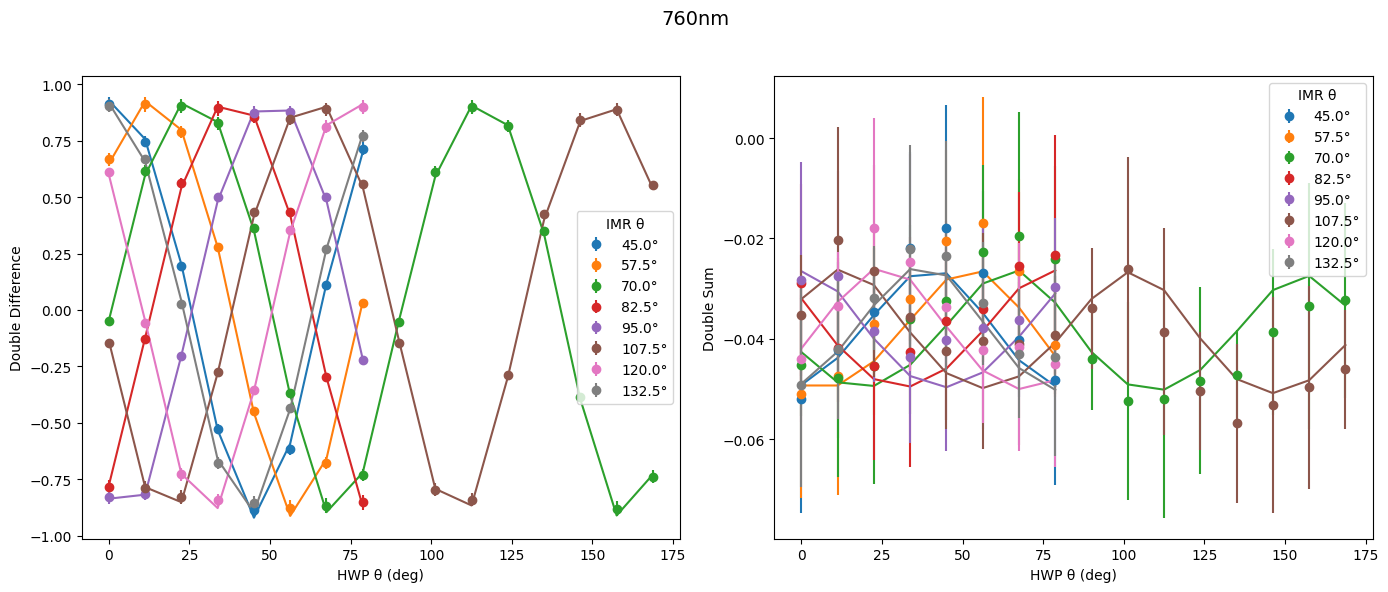

After p0: {'dichroic': {'phi': -2.319739450808706, 'epsilon': 3.3072813307033513e-07, 'theta': -9.38772341177675}, 'flc': {'phi': 2.8059147294609454, 'delta_theta': -0.25267747479473907}, 'optics': {'phi': -1.6258380686445557, 'epsilon': 0.16592468747315048, 'theta': -85.39816427914695}, 'image_rotator': {'phi': 3.153516382784164, 'delta_theta': -1.0}, 'hwp': {'phi': 3.118015284311699, 'delta_theta': -4.99959663299008}, 'lp': {'theta': -4.416439630089947}}
Before p0: {'dichroic': {'phi': -2.319739450808706, 'epsilon': 3.3072813307033513e-07, 'theta': -9.38772341177675}, 'flc': {'phi': 2.8059147294609454, 'delta_theta': -0.25267747479473907}, 'optics': {'phi': -1.6258380686445557, 'epsilon': 0.16592468747315048, 'theta': -85.39816427914695}, 'image_rotator': {'phi': 3.153516382784164, 'delta_theta': -1.0}, 'hwp': {'phi': 3.118015284311699, 'delta_theta': -4.99959663299008}, 'lp': {'theta': -4.416439630089947}}
Iteration #: 5
logl_value: 18.777420025242307
Best Fit Parameters: [-2.586739

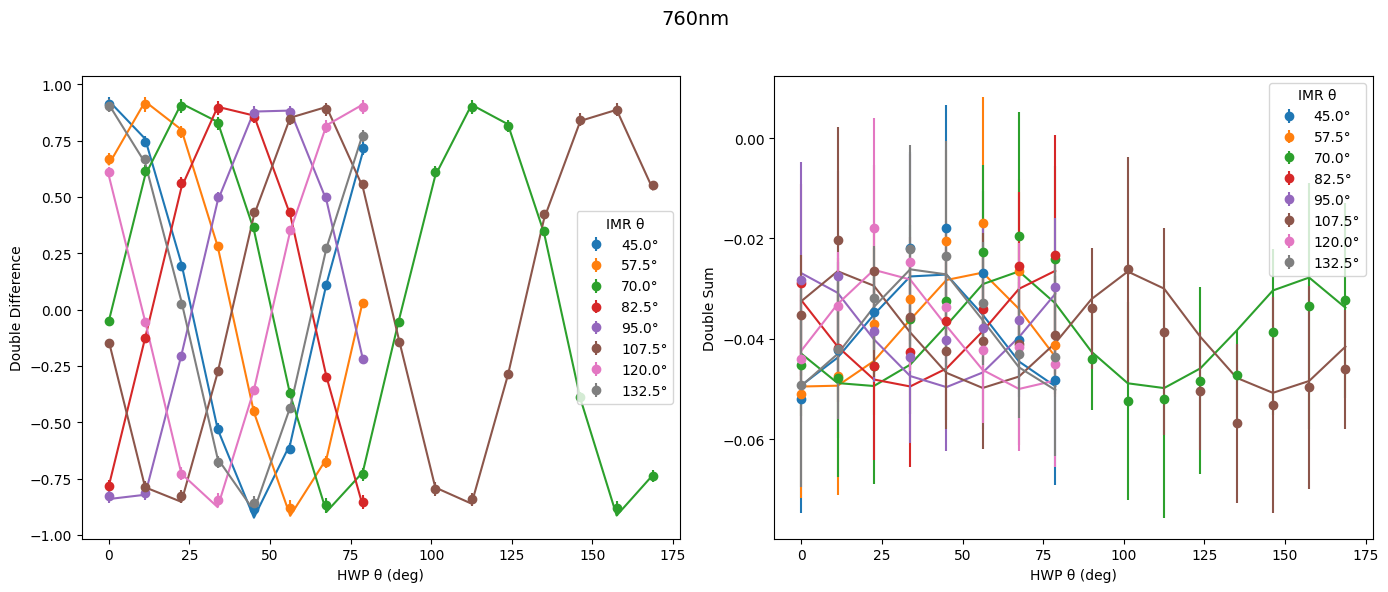

After p0: {'dichroic': {'phi': -2.586739319175951, 'epsilon': 1.8983864961837961e-07, 'theta': -13.558637207672216}, 'flc': {'phi': 2.7997050676167508, 'delta_theta': 0.08300376264146897}, 'optics': {'phi': -1.828879051092375, 'epsilon': 0.16718019529652817, 'theta': -76.08455861415428}, 'image_rotator': {'phi': 3.1635096495975423, 'delta_theta': -1.0}, 'hwp': {'phi': 3.1201799769255008, 'delta_theta': -4.946102902935609}, 'lp': {'theta': 4.998866800001437}}
Before p0: {'dichroic': {'phi': -2.586739319175951, 'epsilon': 1.8983864961837961e-07, 'theta': -13.558637207672216}, 'flc': {'phi': 2.7997050676167508, 'delta_theta': 0.08300376264146897}, 'optics': {'phi': -1.828879051092375, 'epsilon': 0.16718019529652817, 'theta': -76.08455861415428}, 'image_rotator': {'phi': 3.1635096495975423, 'delta_theta': -1.0}, 'hwp': {'phi': 3.1201799769255008, 'delta_theta': -4.946102902935609}, 'lp': {'theta': 4.998866800001437}}
Iteration #: 6
logl_value: 18.767140351523416
Best Fit Parameters: [-2.58

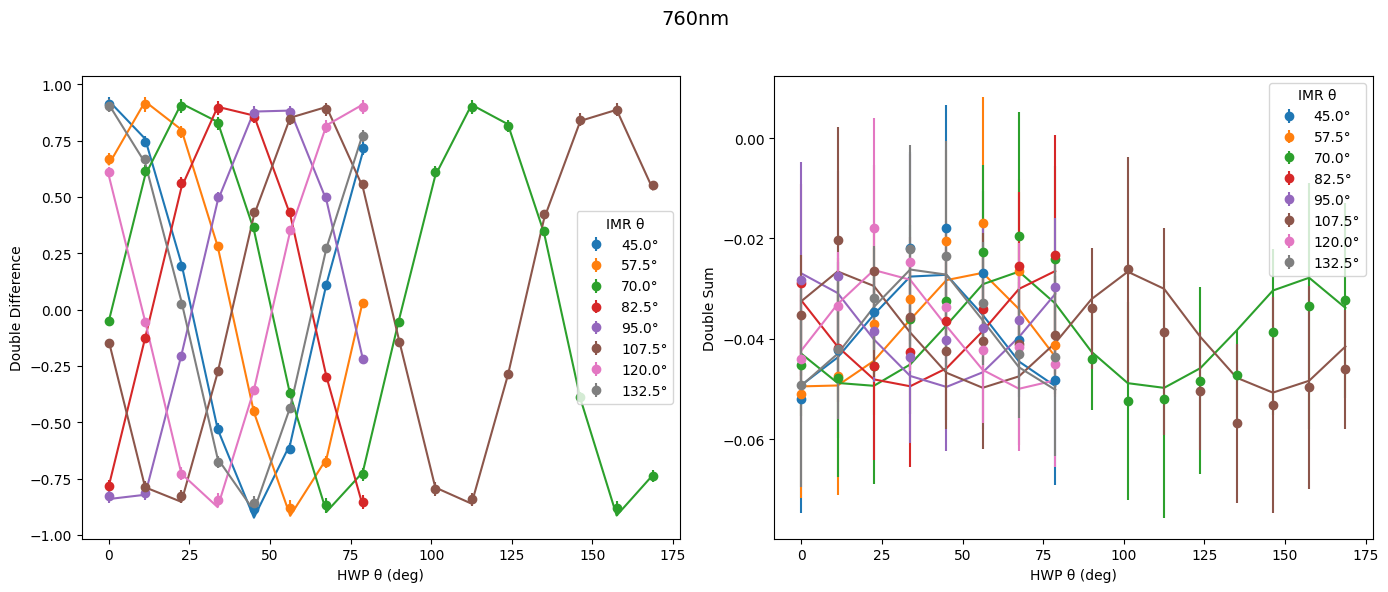

After p0: {'dichroic': {'phi': -2.5880838522444147, 'epsilon': 4.9626368923421285e-09, 'theta': -13.559062246030054}, 'flc': {'phi': 2.8003983992064256, 'delta_theta': 0.12823259059063577}, 'optics': {'phi': -1.8290357399973671, 'epsilon': 0.16720320381784304, 'theta': -75.98624708329874}, 'image_rotator': {'phi': 3.1635876167376193, 'delta_theta': -1.0}, 'hwp': {'phi': 3.1202535480122426, 'delta_theta': -4.999999888781718}, 'lp': {'theta': 4.999972407918147}}


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    # "wollaston": {
    #     "transmission_ratio": (0.8, 1.2)
    # },
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-np.pi, np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "delta_theta": (-1, 1)
    },
    "hwp": {
        "phi": (
             (-2 * np.pi, 2 * np.pi)
        ),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = 1000000
new_logl_value = 0

while abs(previous_logl_value - new_logl_value) > 0.01 * abs(previous_logl_value):
    print("Before p0: " + str(p0))
    if iteration > 1: 
        previous_logl_value = new_logl_value
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    iteration += 1

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

# Step 6: Plot model with best fit

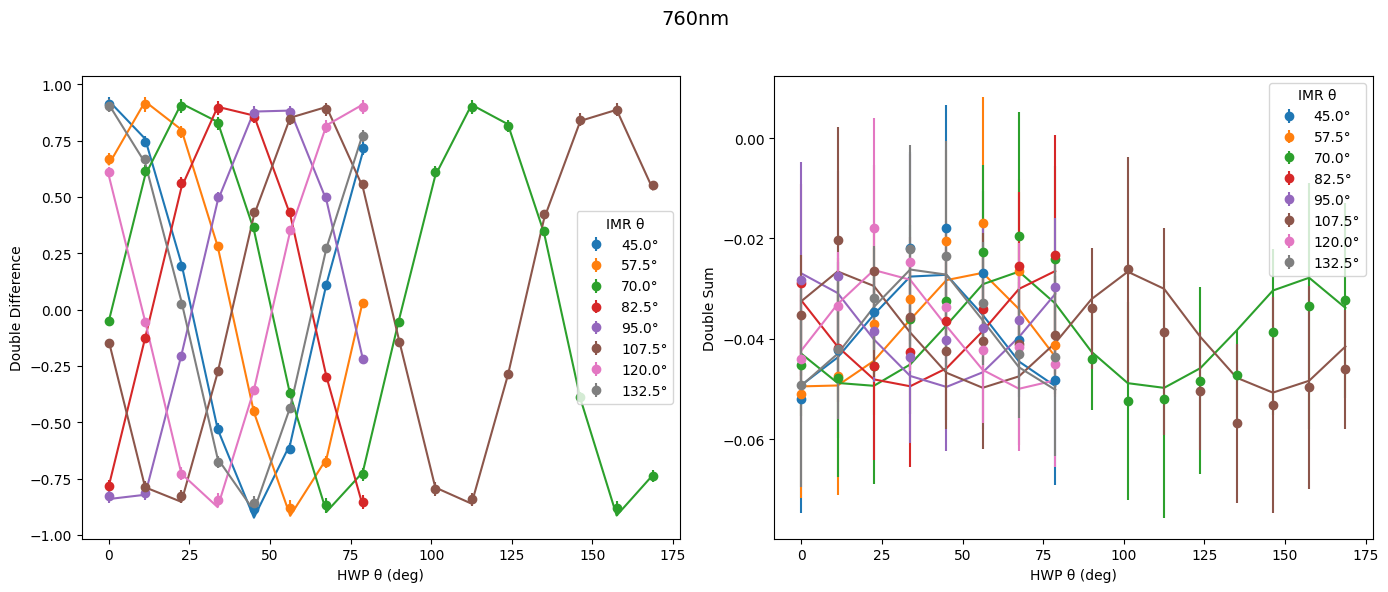

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)